<h1>NYC Rent Affordability Investigation:<br>Forecast Analysis with Prophet</h1>

This is an investigation of rent affordability in NYC using neighborhood-level and borough-level from 2012-2022. 

I am using median rent data from the [Streeteasy Dashboard](https://streeteasy.com/blog/data-dashboard/), and median income data from the [U.S. Census American Community Survey](https://www.census.gov/programs-surveys/acs/data.html).

Here, I'll be using Meta's Prophet package to forecast monthly rent prices 12-24 months into the future.

# Importing packages and modules

In [ ]:
# data management + manipulation
import pandas as pd
import numpy as np
import itertools
import time
from datetime import date, timedelta, datetime
# statistics
from scipy import stats
from scipy.interpolate import make_interp_spline
from diptest import diptest
# plotting
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.gridspec as gridspec
# env vars + Big Query access
import os
import json
from google.cloud import bigquery
from google.oauth2 import service_account
# prophet package
from prophet import Prophet
from prophet.diagnostics import performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.diagnostics import cross_validation
# removing excess logs
import logging
import warnings
warnings.filterwarnings('ignore')
# Suppress Prophet and CmdStanPy logging
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
# Optional: Set matplotlib and other loggers to WARNING
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('urllib3').setLevel(logging.WARNING)
# ensuring CMDSTAN is quiet
os.environ['CMDSTAN_VERBOSE'] = '0'

# Import rent data from Big Query PostgreSQL database

In [36]:
# configure Big Query connection
PROJECT_ID = "rent-affordability"
DATASET_ID = "nyc_analysis"
service_account_info = json.loads(os.environ["GOOGLE_CREDENTIALS_JSON"])
credentials = service_account.Credentials.from_service_account_info(service_account_info)
client = bigquery.Client(project=PROJECT_ID, credentials=credentials)

In [37]:
# importing monthly median rent data at the borough level
rent_query = """
SELECT 
    b.name as borough,
    mr.neighborhood,
    mr.year,
    mr.month,
    AVG(mr.all_apartments) as median_rent_all,
    AVG(mr.one_bedroom) as median_rent_1bdr,
    AVG(mr.three_plus_bedroom) as median_rent_3bdr
FROM nyc_analysis.fact_median_rent mr
JOIN nyc_analysis.ref_neighborhoods n ON mr.neighborhood_id = n.neighborhood_id
JOIN nyc_analysis.ref_boroughs b ON mr.borough_id = b.borough_id
WHERE mr.all_apartments IS NOT NULL
GROUP BY b.name, mr.neighborhood, mr.year, mr.month
ORDER BY b.name, mr.neighborhood, mr.year, mr.month
"""

rent_df = client.query(rent_query).to_dataframe()
rent_df['date'] = pd.to_datetime(rent_df[['year', 'month']].assign(day=1))
rent_df = rent_df.sort_values('date')
print(f"Loaded {len(rent_df)} monthly rent records")
rent_df

Loaded 6456 monthly rent records


,borough,neighborhood,year,month,median_rent_all,median_rent_1bdr,median_rent_3bdr,date
5063,Manhattan,Upper East Side,2010,1,2450.000000000,2350.000000000,8925.000000000,2010-01-01
4525,Manhattan,Midtown West,2010,1,2600.000000000,2650.000000000,0E-9,2010-01-01
5243,Manhattan,Upper West Side,2010,1,2895.000000000,2600.000000000,7000.000000000,2010-01-01
4208,Manhattan,Midtown East,2010,1,2695.000000000,2675.000000000,0E-9,2010-01-01
4028,Manhattan,Midtown,2010,1,3700.000000000,3250.000000000,0E-9,2010-01-01
...,...,...,...,...,...,...,...,...
589,Brooklyn,Bushwick,2024,12,3250.000000000,2900.000000000,3699.000000000,2024-12-01
4524,Manhattan,Midtown South,2024,12,4995.000000000,0E-9,0E-9,2024-12-01
330,Brooklyn,Bedford-Stuyvesant,2024,12,3200.000000000,2829.500000000,3712.500000000,2024-12-01
6382,Queens,Ridgewood,2024,12,3200.000000000,0E-9,0E-9,2024-12-01


let's explicitly set the data types of each column in the rent dataframe

In [38]:
print('Original Datatypes per column:')
print(rent_df.dtypes)
rent_df['neighborhood'] = rent_df['neighborhood'].astype('category')
rent_df['borough'] = rent_df['borough'].astype('category')
rent_df['month'] = rent_df['month'].astype('Int64')
rent_df['median_rent_all'] = rent_df['median_rent_all'].astype('float32')
rent_df['median_rent_1bdr'] = rent_df['median_rent_1bdr'].astype('float32')
rent_df['median_rent_3bdr'] = rent_df['median_rent_3bdr'].astype('float32')
print('New Datatypes per column:')
print(rent_df.dtypes)

Original Datatypes per column:
borough                     object
neighborhood                object
year                         Int64
month                        Int64
median_rent_all             object
median_rent_1bdr            object
median_rent_3bdr            object
date                datetime64[ns]
dtype: object
New Datatypes per column:
borough                   category
neighborhood              category
year                         Int64
month                        Int64
median_rent_all            float32
median_rent_1bdr           float32
median_rent_3bdr           float32
date                datetime64[ns]
dtype: object


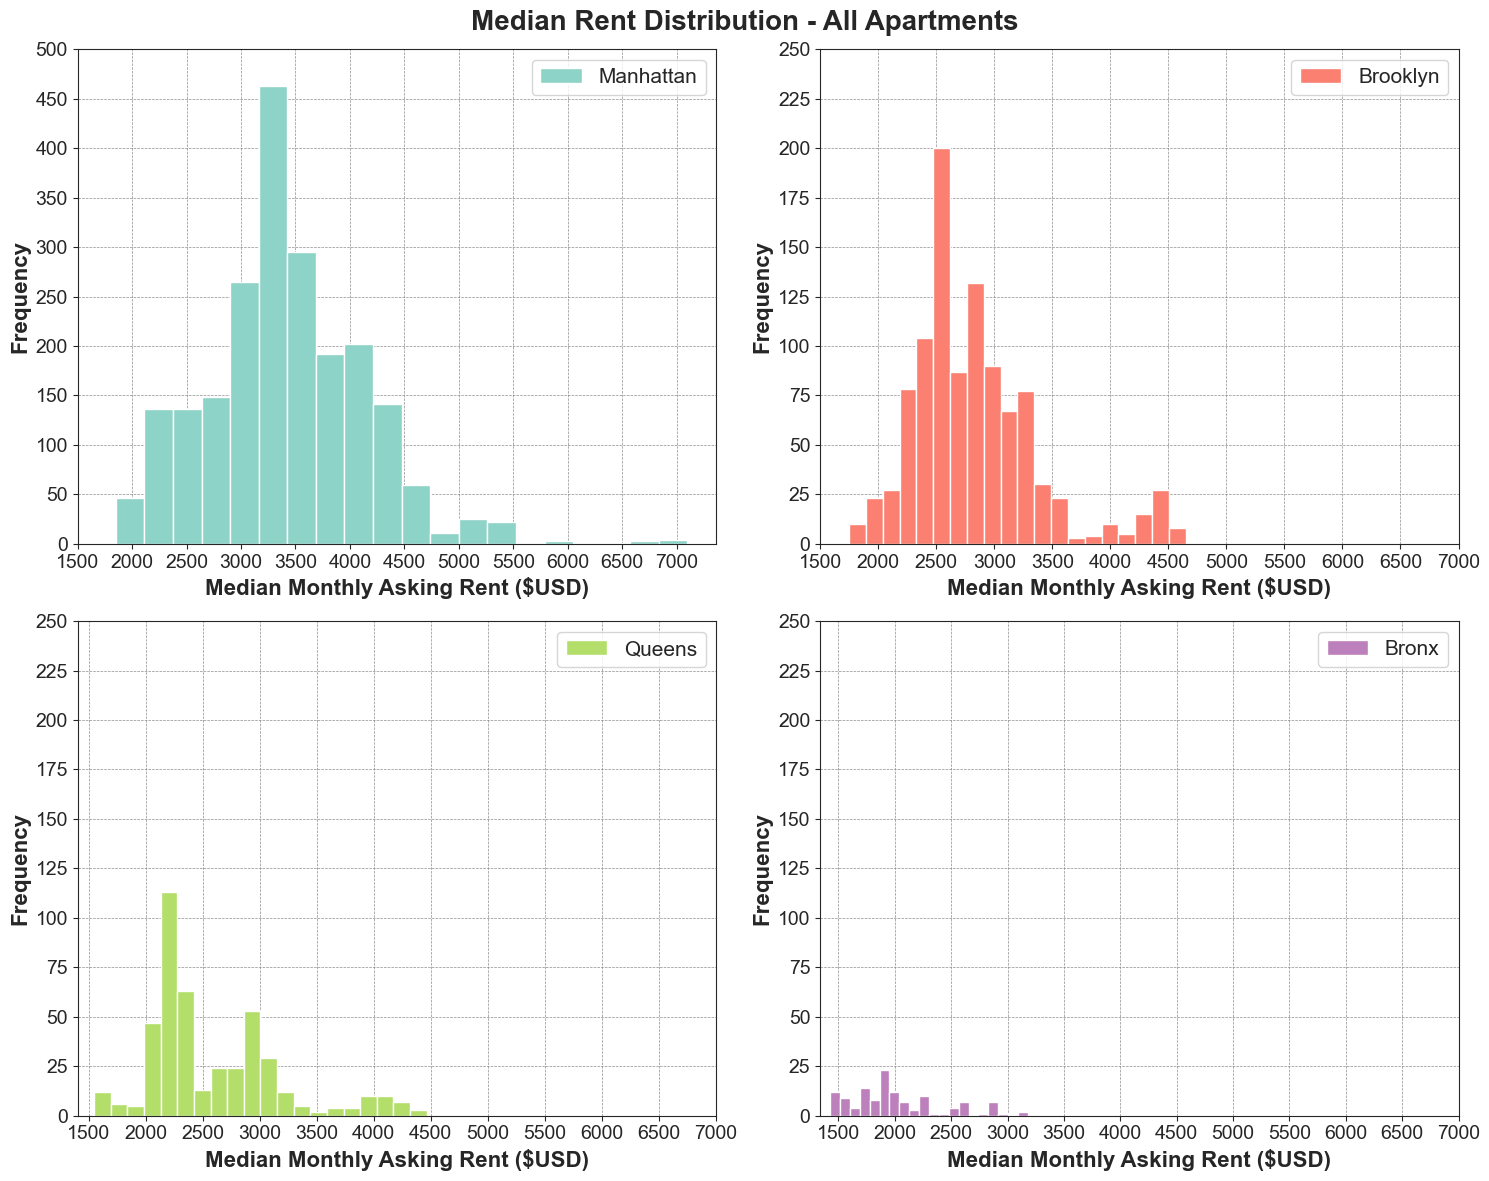

Borough-level distribution plots (calculated during ETL) revealed that the Bronx dataset had very few observations. Because if its lack of data, we will not include it in our analyses.

In [39]:
rent_df = rent_df[rent_df['borough'] != 'Bronx']
rent_df

,borough,neighborhood,year,month,median_rent_all,median_rent_1bdr,median_rent_3bdr,date
5063,Manhattan,Upper East Side,2010,1,2450.0,2350.0,8925.0,2010-01-01
4525,Manhattan,Midtown West,2010,1,2600.0,2650.0,0.0,2010-01-01
5243,Manhattan,Upper West Side,2010,1,2895.0,2600.0,7000.0,2010-01-01
4208,Manhattan,Midtown East,2010,1,2695.0,2675.0,0.0,2010-01-01
4028,Manhattan,Midtown,2010,1,3700.0,3250.0,0.0,2010-01-01
...,...,...,...,...,...,...,...,...
589,Brooklyn,Bushwick,2024,12,3250.0,2900.0,3699.0,2024-12-01
4524,Manhattan,Midtown South,2024,12,4995.0,0.0,0.0,2024-12-01
330,Brooklyn,Bedford-Stuyvesant,2024,12,3200.0,2829.5,3712.5,2024-12-01
6382,Queens,Ridgewood,2024,12,3200.0,0.0,0.0,2024-12-01


# Monthly Rent Price Forecasting

Now, we are going to utilize Meta's Prophet package to create a forecast of furture rent prices!

## Cleaning the Training Datasets

Before we start, it's important that we clean the dataset to remove noise from the dataset. 

In the ETL process, low-volume data was already removed. 

Let's remove outliers based on the presence of null values:

In [40]:
# working only with complete months of data
model_df = rent_df[rent_df['year'] < 2025].copy()[['borough','median_rent_all','date']]
model_df.isnull().sum()

borough            0
median_rent_all    0
date               0
dtype: int64

Evidently, missing data are not represented as Null/NaN values. 

Let's remove outliers from each dataset, so we can utilize the underlying trend beneath the noise.

Manhattan monthly rent data are normally distributed, so we are going to simply exclude values with Z-Scores greater than 2.75 (falling outside of 2.75 Standard Deviations):

In [41]:
borough = 'Manhattan'

df = model_df[model_df['borough'] == borough].reset_index(drop=True).copy()
z = np.abs(stats.zscore(df['median_rent_all']))
outlier_idx = np.where(z > 2.75)[0]
print(f'Dropping {len(outlier_idx)} rows from the {borough} dataset')
df.drop(index=outlier_idx, inplace=True)
manhattan_df = df.set_index('date')
manhattan_df

Dropping 78 rows from the Manhattan dataset


,borough,median_rent_all
date,,
2010-01-01,Manhattan,2450.0
2010-01-01,Manhattan,2600.0
2010-01-01,Manhattan,2895.0
2010-01-01,Manhattan,2695.0
2010-01-01,Manhattan,3700.0
...,...,...
2024-12-01,Manhattan,4300.0
2024-12-01,Manhattan,4900.0
2024-12-01,Manhattan,3950.0


Brooklyn monthly rent data are Right-Skewed, and thus we don't want to use symmetrical z-score outlier bounds because we'd end up cutting out valid data. We could use asymmetrical outlier bounds (e.g. -2.5 SD to 3.75 SD), however, we would have to iteratively adjust those bounds to ensure we are cleaning the data properly. The more simple solution is to use percentile-based removal:

In [42]:
borough = 'Brooklyn'

df = model_df[model_df['borough'] == borough].reset_index(drop=True).copy()
percent_rankings = np.array([stats.percentileofscore(df['median_rent_all'].to_numpy(), value) 
                             for value in df['median_rent_all']])
outlier_idx = np.where((percent_rankings > 95)|((percent_rankings < 5)))[0]
print(f'Dropping {len(outlier_idx)} rows from the {borough} dataset')
df.drop(index=outlier_idx, inplace=True)
brooklyn_df = df.set_index('date')
brooklyn_df

Dropping 215 rows from the Brooklyn dataset


,borough,median_rent_all
date,,
2010-01-01,Brooklyn,2500.0
2010-01-01,Brooklyn,2200.0
2010-02-01,Brooklyn,2500.0
2010-02-01,Brooklyn,2200.0
2010-03-01,Brooklyn,2500.0
...,...,...
2024-12-01,Brooklyn,2850.0
2024-12-01,Brooklyn,3175.0
2024-12-01,Brooklyn,3950.0


Queens monthly rent data had possible Bi-Modal characteristics, with a strong Right-Skewed Distribution. If the dataset is Bimodal, this indicates that we are possibly looking at 2 groups of data that should be processed separately. So, we will confirm it's bimodality using Hartigan's Dip Test:

In [43]:
borough = 'Queens'

df = model_df[model_df['borough'] == borough].reset_index(drop=True)
dip_stat, p_val = diptest(df['median_rent_all'])
if p_val < 0.05:
    print("Data is multimodal (reject unimodal null hypothesis).")
else:
    print("Data is unimodal (fail to reject unimodal null hypothesis).")


Data is multimodal (reject unimodal null hypothesis).


The data is multimodal, indicating that there are 2 different rental markets in Queens, NY: affordable vs. luxury apartments. This likely caused by neighborhoods like LIC (primarily), Astoria, and Flushing, which have relatively large volumes of luxury apartment units. The trough hits its lowest point at $2500, so that is where we will split the data into separate markets.

In [44]:
luxury_df = df[df['median_rent_all'] > 2500].copy()
affordable_df = df[df['median_rent_all'] <= 2500].copy()

The Affordable Queens apartment rent data are normally distributed, so we are going to simply exclude values with Z-Scores greater than 2 (falling outside of 2 Standard Deviations), similar to how we handled Manhattan data:

In [45]:
affordable_df = df[df['median_rent_all'] <= 2500].copy().reset_index(drop=True)
z = np.abs(stats.zscore(affordable_df['median_rent_all']))
outlier_idx = np.where(z > 2)[0]
print(f'Dropping {len(outlier_idx)} rows from the Affordable {borough} dataset')
affordable_df.drop(index=outlier_idx, inplace=True)
queens_affordable_df = affordable_df.set_index('date')
queens_affordable_df

Dropping 1 rows from the Affordable Queens dataset


,borough,median_rent_all
date,,
2013-02-01,Queens,2000.0
2013-03-01,Queens,1950.0
2013-04-01,Queens,2000.0
2013-05-01,Queens,2200.0
2013-06-01,Queens,2100.0
...,...,...
2023-10-01,Queens,2460.0
2023-11-01,Queens,2445.0
2023-12-01,Queens,2500.0


Luxury Queens apartment rent data are Right-Skewed, so we are going to remove outliers beyond the 5th and 95th percentiles (similar to how we handled the Brooklyn dataset):

In [46]:
luxury_df = df[df['median_rent_all'] <= 2500].copy().reset_index(drop=True)
percent_rankings = np.array([stats.percentileofscore(luxury_df['median_rent_all'].to_numpy(), value) 
                             for value in luxury_df['median_rent_all']])
outlier_idx = np.where((percent_rankings > 95)|((percent_rankings < 5)))[0]
print(f'Dropping {len(outlier_idx)} rows from the Luxury {borough} dataset')
luxury_df.drop(index=outlier_idx, inplace=True)
queens_luxury_df = luxury_df.set_index('date')
queens_luxury_df

Dropping 47 rows from the Luxury Queens dataset


,borough,median_rent_all
date,,
2013-02-01,Queens,2000.0
2013-03-01,Queens,1950.0
2013-04-01,Queens,2000.0
2013-05-01,Queens,2200.0
2013-06-01,Queens,2100.0
...,...,...
2023-03-01,Queens,2497.0
2023-03-01,Queens,2000.0
2023-10-01,Queens,2460.0


Let's prepare the datasets to for historical forecast simulation

In [47]:
# averaging all median rent values that have the same date
manhattan_df = manhattan_df.groupby('date')['median_rent_all'].mean().reset_index()
brooklyn_df = brooklyn_df.groupby('date')['median_rent_all'].mean().reset_index()
queens_affordable_df = queens_affordable_df.groupby('date')['median_rent_all'].mean().reset_index()
queens_luxury_df = queens_luxury_df.groupby('date')['median_rent_all'].mean().reset_index()

# renaming columns for prophet model use
manhattan_df = manhattan_df.rename(columns={'date':'ds', 'median_rent_all':'y'})
brooklyn_df = brooklyn_df.rename(columns={'date':'ds', 'median_rent_all':'y'})
queens_affordable_df = queens_affordable_df.rename(columns={'date':'ds', 'median_rent_all':'y'})
queens_luxury_df = queens_luxury_df.rename(columns={'date':'ds', 'median_rent_all':'y'})

## Hyperparameter Tuning via Cross-validation

Prophet has several hyperparameters that can be tuned to improve forecast accuracy, including:
1. changepoint_prior_scale range: (0.001, 0.5) 
2. seasonality_prior_scale range: (0.01, 10)
3. holidays_prior_scale range: (0.01, 10) 
5. changepoint_range: (0.5, 0.95)

We are going to generate all combinations of hyperparameters, and create historical simulations using each combo. Then we will compare the results of each forecast simulation to determine which combination of parameters produces the highest accuracy. We know that there is yearly seasonality in each dataset, and that the seasonality is additive wherein the amplitude of the seasonal trends don't really change over time. 

In [53]:
# data coverage
print(f'Manhattan:\n From {manhattan_df['ds'].min()} to {manhattan_df['ds'].max()}\n'
      f'Brooklyn: \n From {brooklyn_df['ds'].min()} to {brooklyn_df['ds'].max()}\n'
      f'Queens_Luxury: \n From {queens_luxury_df['ds'].min()} to {queens_luxury_df['ds'].max()}\n'
      f'Queens_Affordable: \n From {queens_affordable_df['ds'].min()} to {queens_affordable_df['ds'].max()} '
      
       )

Manhattan:
 From 2010-01-01 00:00:00 to 2024-12-01 00:00:00
Brooklyn: 
 From 2010-01-01 00:00:00 to 2024-12-01 00:00:00
Queens_Luxury: 
 From 2013-02-01 00:00:00 to 2024-02-01 00:00:00
Queens_Affordable: 
 From 2013-02-01 00:00:00 to 2024-04-01 00:00:00 


We will now simulate historical forecast models using each combination of hyperparameters for each dataframe!

### We'll run this remotely to allow continuous, parallel execution for each borough.

In [ ]:
df_names = ['Manhattan', 'Brooklyn', 'Queens_Affordable', 'Queens_Luxury']
# we want to use only RELEVANT historical data, so we are going to start all dfs post-2017
manhattan_df = manhattan_df[manhattan_df['ds'] >= datetime(2017,1,1)]
brooklyn_df = brooklyn_df[brooklyn_df['ds'] >= datetime(2017,1,1)]
queens_affordable_df = queens_affordable_df[queens_affordable_df['ds'] >= datetime(2017,1,1)]
queens_luxury_df = queens_luxury_df[queens_luxury_df['ds'] >= datetime(2017,1,1)]
# placing preprocessed dataframes into an accessible list
predictor_dfs = [manhattan_df, brooklyn_df, queens_affordable_df, queens_luxury_df]

# Define hyperparameter grid
param_grid = {  
    "changepoint_prior_scale": [0.001, 0.01, 0.05, 0.1, 0.5],
    "seasonality_prior_scale": [0.01, 0.1, 1.0, 5.0, 10.0],
    'holidays_prior_scale': [0.01, 0.1, 1.0, 5.0, 10.0],
    'changepoint_range': [0.8, 0.85, 0.9, 0.95]
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
# adding fixed parameters to combos
for param in all_params:
    param['seasonality_mode'] = 'additive'
    param['yearly_seasonality'] = True

print(f"Testing {len(all_params)} parameter combinations\n")

# Cross-validation parameters
CV_INITIAL_DAYS = 730   # 2 years, minimum training period
CV_HORIZON_DAYS = 365   # forecast 1 year ahead
CV_PERIOD_DAYS = 90     # new fold every 90 days
PANDEMIC_CUTOFF = pd.Timestamp("2019-01-01")

results_dict = {}
start_time = time.time()

for i, df in enumerate(predictor_dfs):
    print(f"Processing {df_names[i]} Dataset")
    print(f"Data range: {df['ds'].min()} to {df['ds'].max()}")
    print(f"Total observations: {len(df)}")

    # Calculate data span in days
    data_span_days = (df['ds'].max() - df['ds'].min()).days

    # We want the initial training data to be smaller to allow more folds
    if data_span_days < 1460:  # Less than 4 years
        cv_initial = f"{int(data_span_days * 0.4)} days"  # 40% of available data
    else:
        cv_initial = f"{CV_INITIAL_DAYS} days"
    
    # define cross validation arguments
    cv_horizon = f"{CV_HORIZON_DAYS} days"
    cv_period = f"{CV_PERIOD_DAYS} days"
    
    # storing stats
    rmses = [] # storing the RMSEs for each param combo
    mapes = [] # storing the MAPEs for each param combo
    maes = [] # storing the MAEs for each param combo
    num_cutoffs = []

    # Use cross validation to evaluate each parameter combination
    for idx, params in enumerate(all_params):
        if idx % 50 == 0:
            elapsed = time.time() - start_time
            rate = idx / elapsed if idx > 0 else 0
            remaining = (len(all_params) - idx) / rate if rate > 0 else 0
            print(f"Progress: {idx}/{len(all_params)} combinations tested | "
                  f"Elapsed: {elapsed/60:.1f}min | "
                  f"Est. remaining: {remaining/60:.1f}min")

        try:
            m = Prophet(**params).fit(df)  # Fit model with given params
            # perform cross-validation with multiple folds and an expanding training window
            df_cv = cross_validation(m, 
                                     initial=cv_initial, 
                                     horizon=cv_horizon,
                                     period=cv_period,
                                     parallel='threads')
            # Keep only pandemic-era cutoffs
            df_cv = df_cv[df_cv["cutoff"] >= PANDEMIC_CUTOFF]
            if df_cv.empty:
                raise ValueError("No valid pandemic-era cutoffs available.")
            # calculate performance metrics at each horizon point
            df_p = performance_metrics(df_cv, rolling_window=1)

            # store metrics, avg. across all folds with different horizons and cutoffs
            rmses.append(df_p['rmse'].mean())
            mapes.append(df_p['mape'].mean())
            maes.append(df_p['mae'].mean())
            num_cutoffs.append(len(df_cv['cutoff'].unique()))
            if len(df_cv['cutoff'].unique()) < 3:
                raise ValueError(f"Too few CV cutoffs ({len(df_cv['cutoff'].unique())}).")

        except Exception as e:
            print(f"Error with params {idx}: {str(e)}")
            rmses.append(np.nan)
            mapes.append(np.nan)
            maes.append(np.nan)
            num_cutoffs.append(0)

    # create a dataframe of the best parameters
    tuning_results = pd.DataFrame(all_params)
    tuning_results['rmse'] = rmses
    tuning_results['mape'] = mapes
    tuning_results['mae'] = maes
    tuning_results['num_cutoffs'] = num_cutoffs

    # remove failed combinations
    tuning_results = tuning_results.dropna()
    # sort by MAPE
    tuning_results = tuning_results.sort_values('mape').reset_index(drop=True)

    # store the best params
    best_params = dict(tuning_results.iloc[0])
    results_dict[df_names[i]] = best_params

elapsed = time.time() - start_time
print(f"--- {elapsed/60:.2f} minutes elapsed ---")

# Display final results
for borough, params in results_dict.items():
    print(f"\nBest Parameters for {borough}:")
    print(f"  MAPE: {params['mape']:.2f}%")
    print(f"  RMSE: ${params['rmse']:.2f}")
    print(f"  MAE: ${params['mae']:.2f}")
    print(f"  Changepoint Prior Scale: {params['changepoint_prior_scale']}")
    print(f"  Seasonality Prior Scale: {params['seasonality_prior_scale']}")
    print(f"  Holidays Prior Scale: {params['holidays_prior_scale']}")
    print(f"  Changepoint Range: {params['changepoint_range']}")

### Let's interpret these results

Let's see which parameter combos produce the lowest Mean Absolute Percentage Error (MAPE), meaning the forecasted data have minimal difference from actual historical values

In [68]:
df_names = ['Manhattan','Brooklyn','Queens_Affordable','Queens_Luxury']

dfs = {}
for borough in df_names:
    df = pd.read_csv(f'data/tuning_results_{borough}.csv')
    dfs[f'{borough}'] = df

In [69]:
i = 0
print(f'{df_names[i]}')
dfs[f'{df_names[i]}'].loc[dfs[f'{df_names[i]}']['rmse'] == dfs[f'{df_names[i]}']['rmse'].min()]

Manhattan


,changepoint_prior_scale,seasonality_prior_scale,holidays_prior_scale,changepoint_range,seasonality_mode,yearly_seasonality,rmse,mape,mae,num_cutoffs
0,0.1,0.01,0.10,0.95,additive,True,438.211227,0.086514,323.558515,20
1,0.1,0.01,0.01,0.95,additive,True,438.211227,0.086514,323.558515,20
2,0.1,0.01,5.00,0.95,additive,True,438.211227,0.086514,323.558515,20
3,0.1,0.01,1.00,0.95,additive,True,438.211227,0.086514,323.558515,20
4,0.1,0.01,10.00,0.95,additive,True,438.211227,0.086514,323.558515,20


In [70]:
i = 1
print(f'{df_names[i]}')
dfs[f'{df_names[i]}'].loc[dfs[f'{df_names[i]}']['rmse'] == dfs[f'{df_names[i]}']['rmse'].min()]

Brooklyn


,changepoint_prior_scale,seasonality_prior_scale,holidays_prior_scale,changepoint_range,seasonality_mode,yearly_seasonality,rmse,mape,mae,num_cutoffs
0,0.01,0.01,5.00,0.85,additive,True,274.892828,0.080745,236.021481,20
1,0.01,0.01,1.00,0.85,additive,True,274.892828,0.080745,236.021481,20
2,0.01,0.01,0.10,0.85,additive,True,274.892828,0.080745,236.021481,20
3,0.01,0.01,10.00,0.85,additive,True,274.892828,0.080745,236.021481,20
4,0.01,0.01,0.01,0.85,additive,True,274.892828,0.080745,236.021481,20


In [71]:
i = 2
print(f'{df_names[i]}')
dfs[f'{df_names[i]}'].loc[dfs[f'{df_names[i]}']['rmse'] == dfs[f'{df_names[i]}']['rmse'].min()]

Queens_Affordable


,changepoint_prior_scale,seasonality_prior_scale,holidays_prior_scale,changepoint_range,seasonality_mode,yearly_seasonality,rmse,mape,mae,num_cutoffs
0,0.001,0.01,0.01,0.95,additive,True,213.899448,0.083197,183.52247,14
1,0.001,0.01,0.10,0.95,additive,True,213.899448,0.083197,183.52247,14
2,0.001,0.01,1.00,0.95,additive,True,213.899448,0.083197,183.52247,14
3,0.001,0.01,5.00,0.95,additive,True,213.899448,0.083197,183.52247,14
4,0.001,0.01,10.00,0.95,additive,True,213.899448,0.083197,183.52247,14


In [72]:
i = 3
print(f'{df_names[i]}')
dfs[f'{df_names[i]}'].loc[dfs[f'{df_names[i]}']['rmse'] == dfs[f'{df_names[i]}']['rmse'].min()]

Queens_Luxury


,changepoint_prior_scale,seasonality_prior_scale,holidays_prior_scale,changepoint_range,seasonality_mode,yearly_seasonality,rmse,mape,mae,num_cutoffs
0,0.001,0.01,0.01,0.95,additive,True,238.754539,0.059107,186.71572,20
1,0.001,0.01,0.10,0.95,additive,True,238.754539,0.059107,186.71572,20
2,0.001,0.01,1.00,0.95,additive,True,238.754539,0.059107,186.71572,20
3,0.001,0.01,5.00,0.95,additive,True,238.754539,0.059107,186.71572,20
4,0.001,0.01,10.00,0.95,additive,True,238.754539,0.059107,186.71572,20


It appears that the holidays prior scale doesn't matter. All 5 parameter options produce the same accuracy. What matters more are the other parameters:
- changepoint_prior_scale
- seasonality_prior_scale
- changepoint_range
- seasonality_mode
- yearly_seasonality

In [86]:
bk_df = pd.read_csv('data/Brooklyn_best_parameters.csv')
qu_df = pd.read_csv('data/Queens_best_parameters.csv')
mh_df = pd.read_csv('data/Manhattan_best_parameters.csv')

best_params = mh_df.merge(pd.merge(bk_df, qu_df, how='outer', on=['borough','mape','rmse','mae','changepoint_prior_scale','seasonality_prior_scale','holidays_prior_scale','changepoint_range']),
                          how='outer', on=['borough','mape','rmse','mae','changepoint_prior_scale','seasonality_prior_scale','holidays_prior_scale','changepoint_range'])

param_dicts = {}
for borough in df_names:
    dict = {}
    dict['changepoint_prior_scale'] = best_params[best_params['borough'] == borough]['changepoint_prior_scale'].values
    dict['seasonality_prior_scale'] = best_params[best_params['borough'] == borough]['seasonality_prior_scale'].values
    dict['holidays_prior_scale'] = best_params[best_params['borough'] == borough]['holidays_prior_scale'].values
    dict['changepoint_range'] = best_params[best_params['borough'] == borough]['changepoint_range'].values
    param_dicts[f'{borough}'] = dict

array([0.001])

Now that we know what the best parameter combos are for each population of apartment rental groups, we're now going to forecast that data our over the next half decade.

## Generating a Forecast of Future Rent Prices

In [74]:
# we want to use only RELEVANT historical data, so we are going to start all dfs post-2017
manhattan_df = manhattan_df[manhattan_df['ds'] >= datetime(2017,1,1)]
brooklyn_df = brooklyn_df[brooklyn_df['ds'] >= datetime(2017,1,1)]
queens_affordable_df = queens_affordable_df[queens_affordable_df['ds'] >= datetime(2017,1,1)]
queens_luxury_df = queens_luxury_df[queens_luxury_df['ds'] >= datetime(2017,1,1)]
predictor_dfs = [manhattan_df, brooklyn_df, queens_affordable_df, queens_luxury_df]

Manhattan
forecast start date on 2024-12-01 00:00:00


15:09:00 - cmdstanpy - INFO - Chain [1] start processing
15:09:04 - cmdstanpy - INFO - Chain [1] done processing


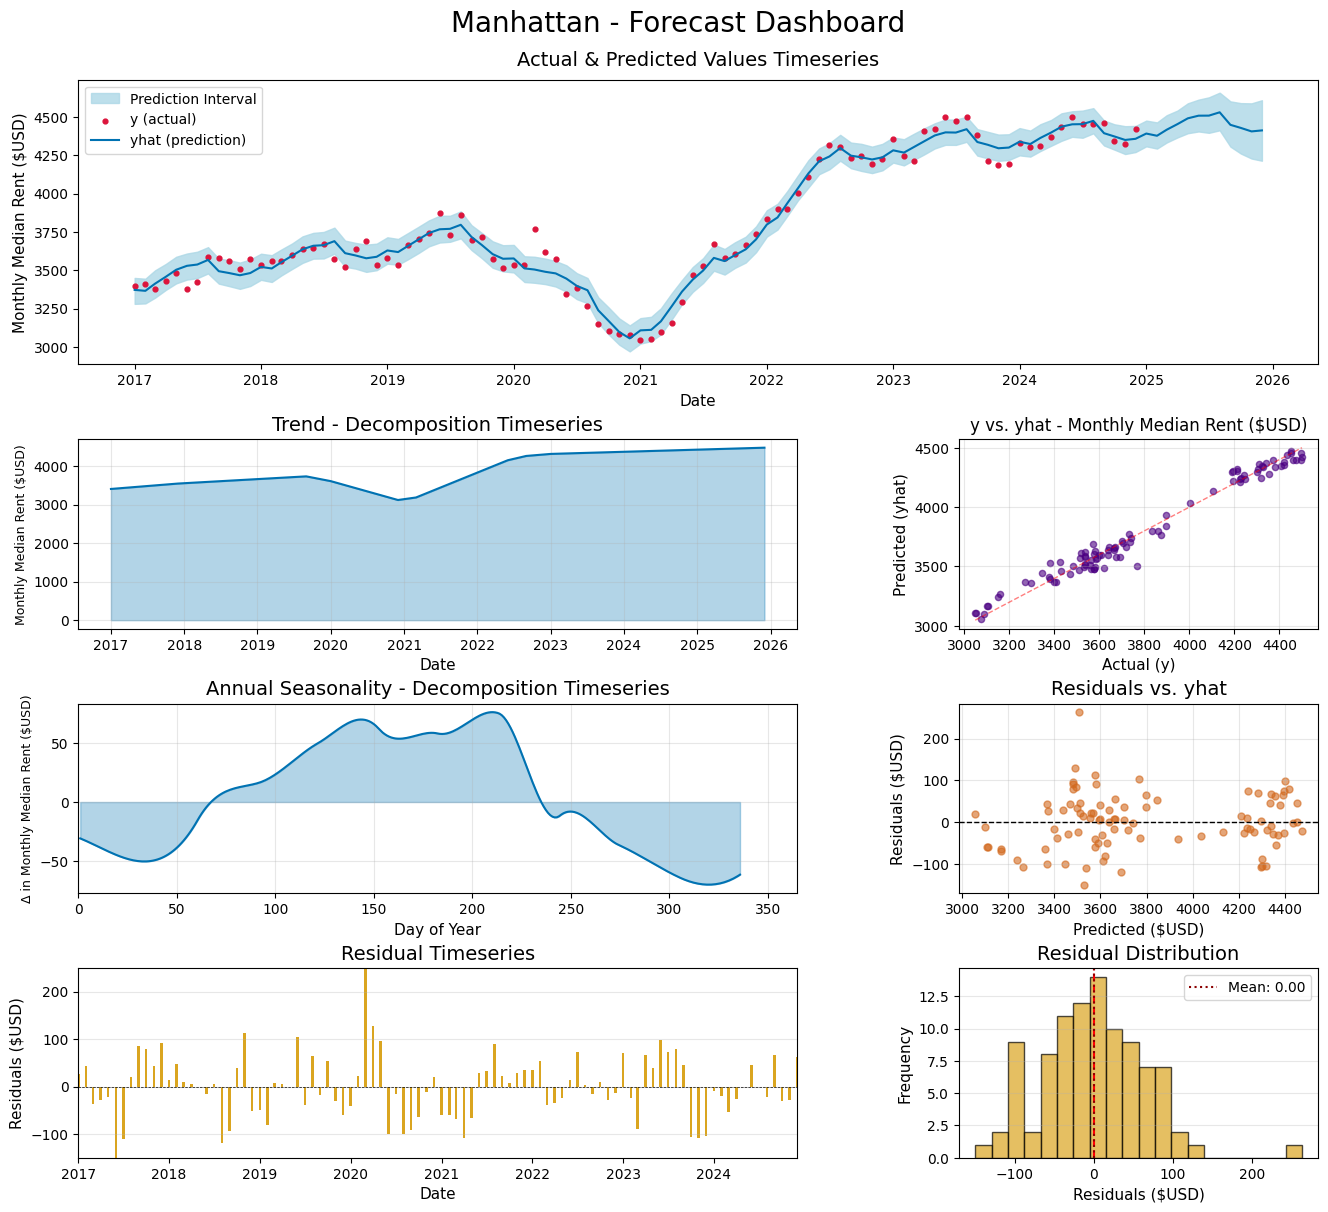

Brooklyn
forecast start date on 2024-12-01 00:00:00


15:09:17 - cmdstanpy - INFO - Chain [1] start processing
15:09:18 - cmdstanpy - INFO - Chain [1] done processing


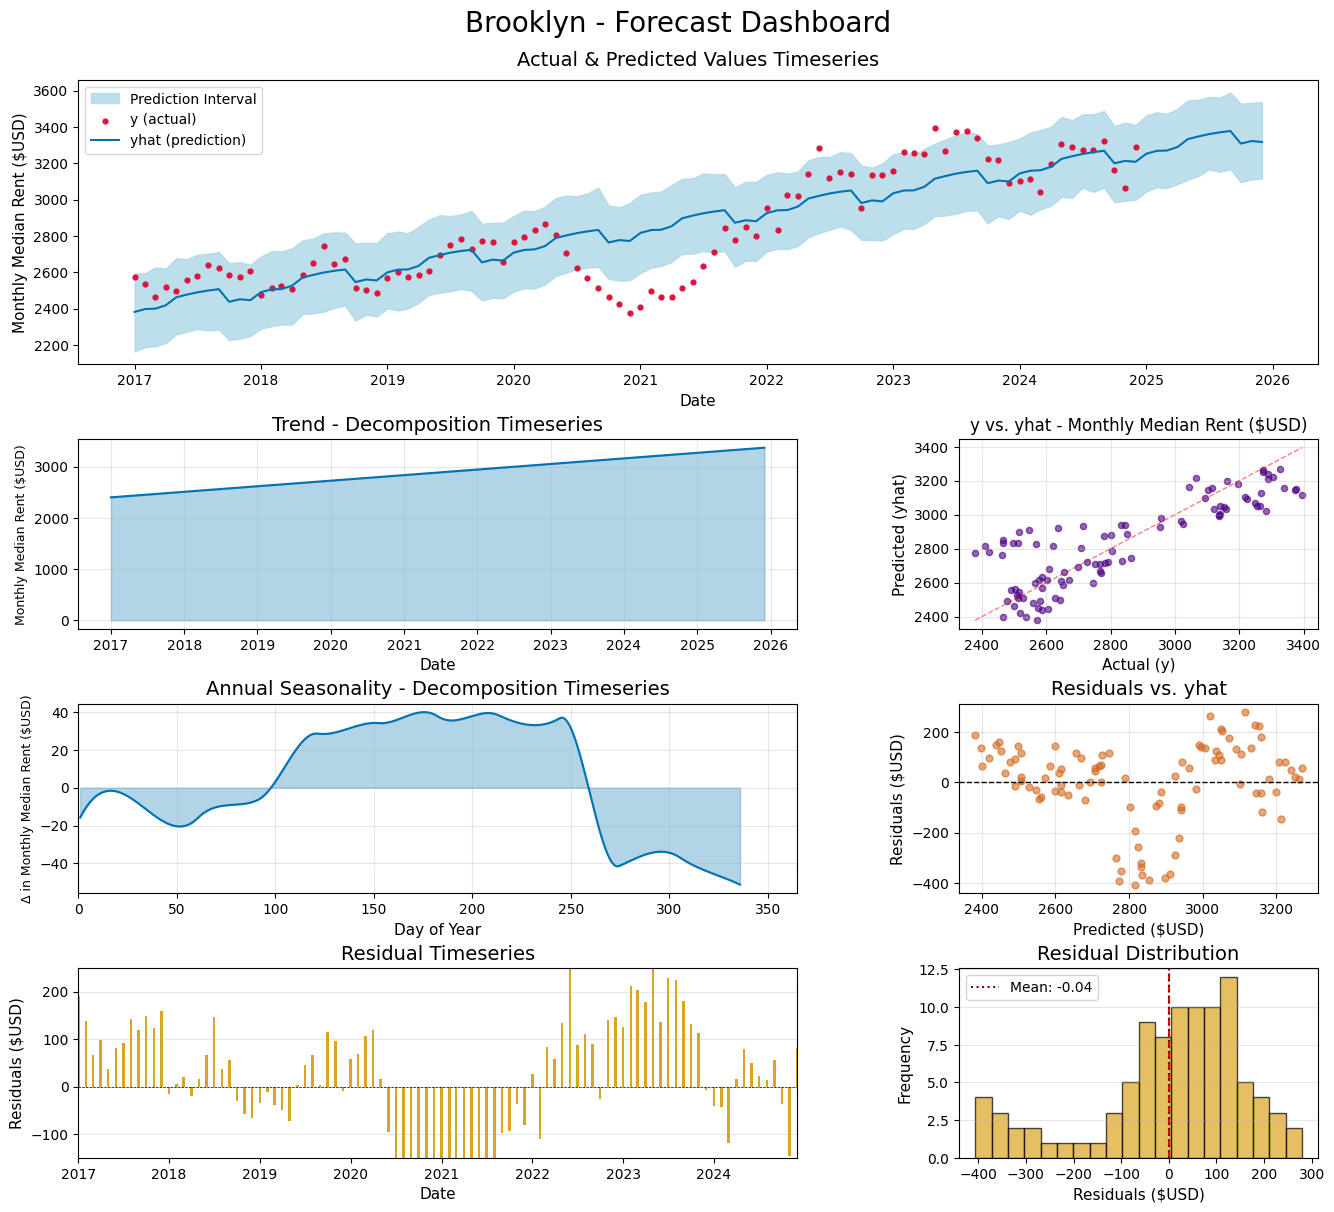

15:09:19 - cmdstanpy - INFO - Chain [1] start processing


Queens_Affordable
forecast start date on 2024-04-01 00:00:00


15:09:20 - cmdstanpy - INFO - Chain [1] done processing


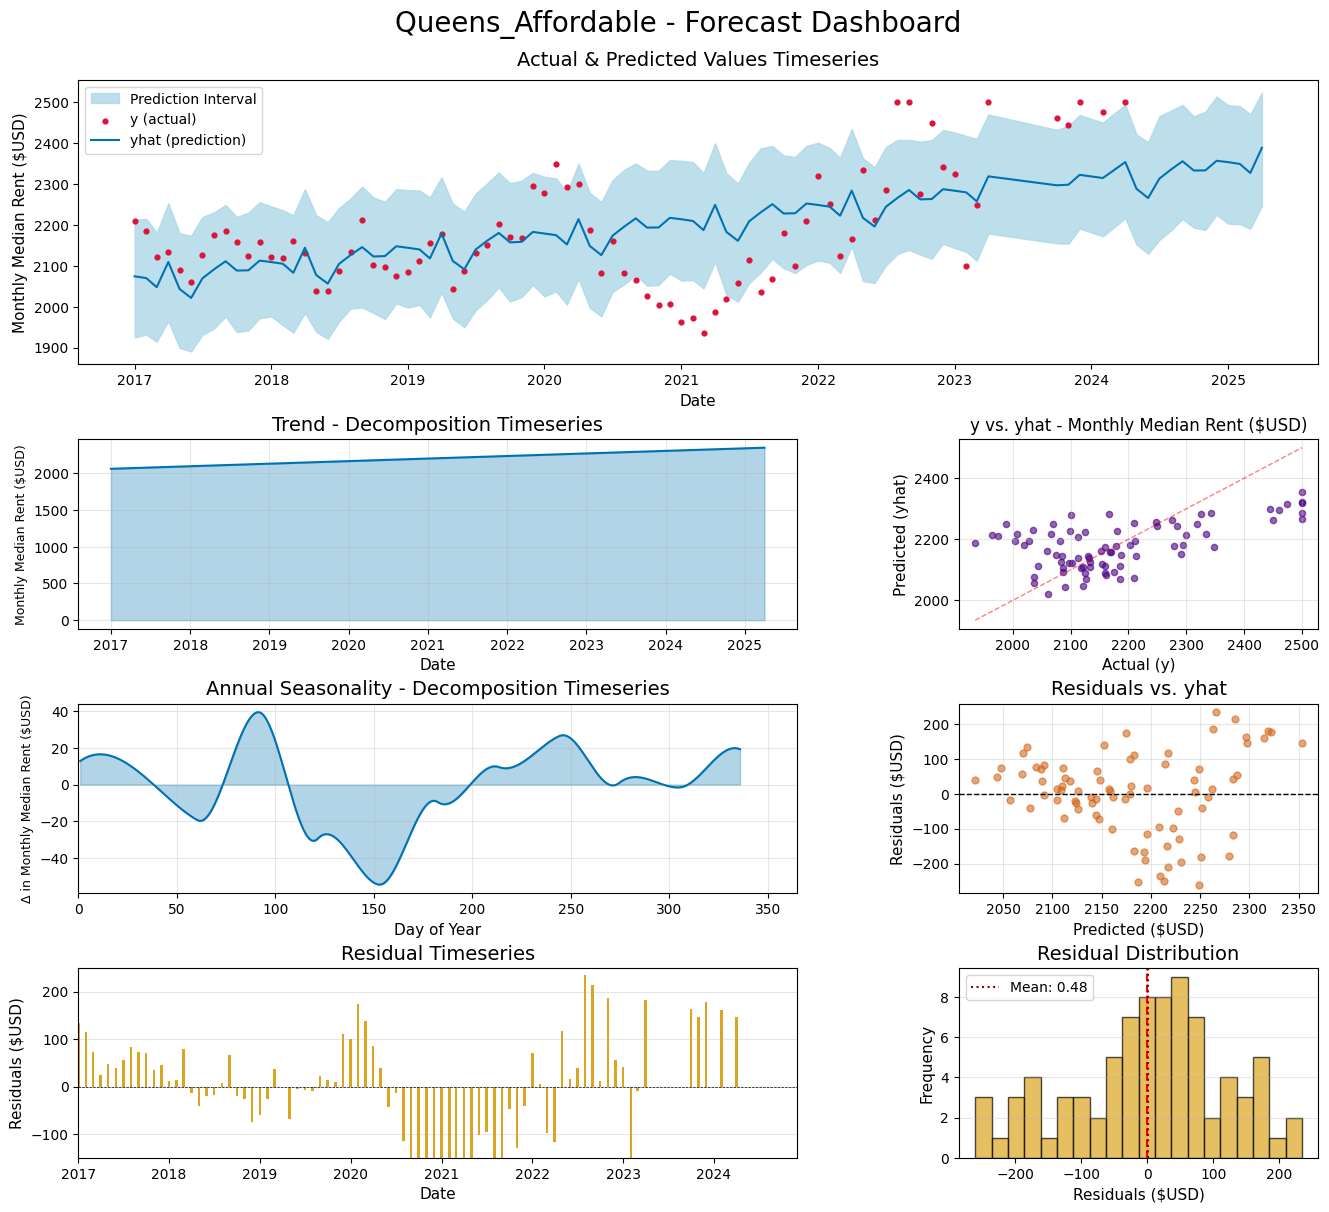

15:09:21 - cmdstanpy - INFO - Chain [1] start processing


Queens_Luxury
forecast start date on 2024-02-01 00:00:00


15:09:22 - cmdstanpy - INFO - Chain [1] done processing


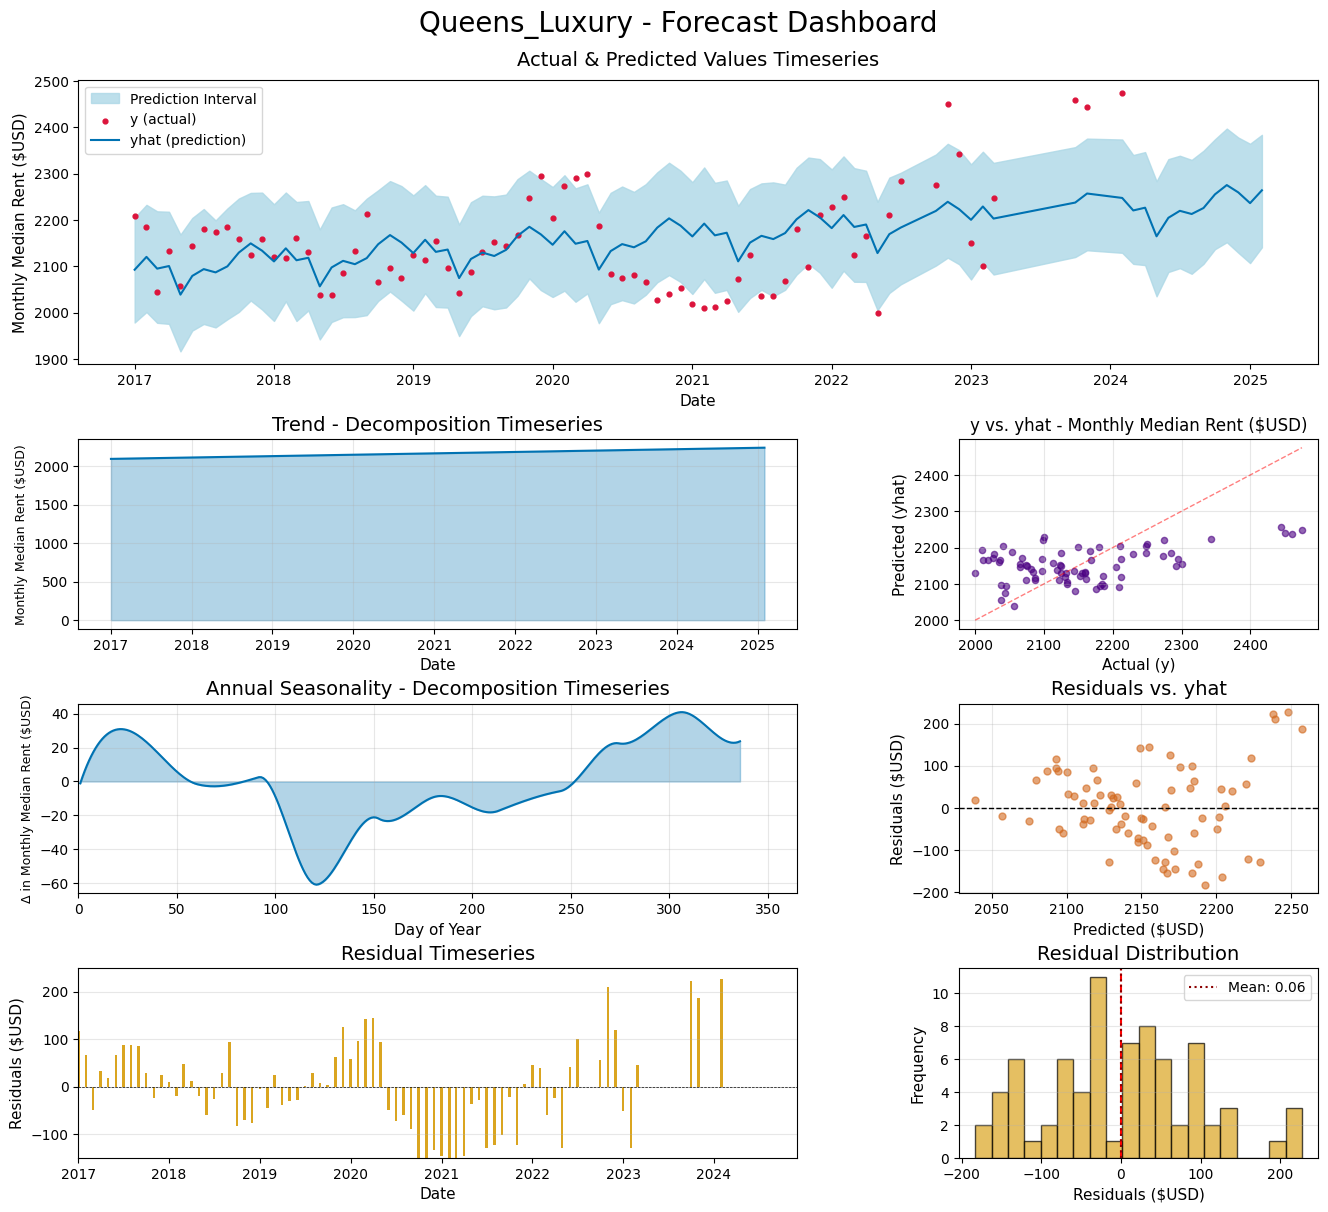

In [224]:
predictor_dfs = [manhattan_df, brooklyn_df, queens_affordable_df, queens_luxury_df]
df_names = ['Manhattan','Brooklyn','Queens_Affordable','Queens_Luxury']
forecast_dfs = []

for i, borough in enumerate(df_names):
    print(f'{borough}')
    forecast_start_date = predictor_dfs[i]['ds'].max()
    print(f'forecast start date on {forecast_start_date}')

    model = Prophet(changepoint_prior_scale = param_dicts[f'{borough}']['changepoint_prior_scale'],
                    seasonality_prior_scale = param_dicts[f'{borough}']['seasonality_prior_scale'],
                    changepoint_range = param_dicts[f'{borough}']['changepoint_range'][0], 
                    seasonality_mode = 'additive',
                    )
    model.fit(predictor_dfs[i])
    future = model.make_future_dataframe(periods=12, freq='MS')
    forecast_df = model.predict(future)
    forecast_dfs.append(forecast_df) 
    
    # creating a dashboard to evaluate the model for each borough
    fig = plt.figure(figsize=(16, 14))
    gs = gridspec.GridSpec(4, 2, figure=fig, height_ratios=[1.5, 1, 1, 1], 
                          width_ratios=[2, 1], hspace=0.35, wspace=0.3)

    fig.suptitle(f'{borough} - Forecast Dashboard', size=20, y=0.93)
    
    ### Time Series of actual & predicted values - Entire TOP Row ###
    ax_timeseries = fig.add_subplot(gs[0, :])
    ax_timeseries.fill_between(forecast_dfs[i]['ds'], 
                               forecast_dfs[i]['yhat_lower'], 
                               forecast_dfs[i]['yhat_upper'], 
                               alpha=0.8, color='lightblue', 
                               label='Prediction Interval')
    ax_timeseries.scatter(predictor_dfs[i]['ds'], predictor_dfs[i]['y'], 
                         s=12, color='crimson', label='y (actual)')
    ax_timeseries.plot(forecast_dfs[i]['ds'], forecast_dfs[i]['yhat'], 
                      color='#0072B2', linewidth=1.5, label='yhat (prediction)')
    ax_timeseries.set_title('Actual & Predicted Values Timeseries', size=14, pad=10)
    ax_timeseries.set_xlabel('Date', size=11)
    ax_timeseries.set_ylabel('Monthly Median Rent ($USD)', size=11)
    ax_timeseries.legend()
    ax_timeseries.tick_params(axis='both', labelsize=10)
    
    ### Trend Timeseries - 2nd Row, Left Side ###
    ax_trend = fig.add_subplot(gs[1, 0])
    trend_data = forecast_dfs[i][['ds', 'trend']].copy()
    ax_trend.plot(trend_data['ds'], trend_data['trend'], 
                 color='#0072B2', linewidth=1.5)
    ax_trend.fill_between(trend_data['ds'], trend_data['trend'], 
                         alpha=0.3, color='#0072B2')
    ax_trend.set_title('Trend - Decomposition Timeseries', size=14)
    ax_trend.set_xlabel('Date', size=11)
    ax_trend.set_ylabel('Monthly Median Rent ($USD)', size=9)
    ax_trend.tick_params(axis='both', labelsize=10)
    ax_trend.grid(True, alpha=0.3)
    
    # y vs. yhat scatterplot - 2nd Row, Right Side
    ax_scatter = fig.add_subplot(gs[1, 1])
    ax_scatter.scatter(predictor_dfs[i]['y'], 
                      forecast_dfs[i][forecast_dfs[i]['ds'] <= predictor_dfs[i]['ds'].max()]['yhat'], 
                      s=20, color='indigo', alpha=0.6)
    # Add diagonal reference line
    min_val = min(predictor_dfs[i]['y'].min(), 
                  forecast_dfs[i][forecast_dfs[i]['ds'] <= predictor_dfs[i]['ds'].max()]['yhat'].min())
    max_val = max(predictor_dfs[i]['y'].max(), 
                  forecast_dfs[i][forecast_dfs[i]['ds'] <= predictor_dfs[i]['ds'].max()]['yhat'].max())
    ax_scatter.plot([min_val, max_val], [min_val, max_val], 
                   'r--', linewidth=1, alpha=0.5)
    ax_scatter.set_title('y vs. yhat - Monthly Median Rent ($USD)', size=12)
    ax_scatter.set_xlabel('Actual (y)', size=11)
    ax_scatter.set_ylabel('Predicted (yhat)', size=11)
    ax_scatter.tick_params(axis='both', labelsize=10)
    ax_scatter.grid(True, alpha=0.3)
    
    ### Annual Seasonality line plot - 3rd Row, Left Side ###
    ax_seasonality = fig.add_subplot(gs[2, 0])
    # Extract one full cycle of yearly seasonality - contains smooth Fourier-based seasonality
    seasonal_data = forecast_dfs[i][['ds', 'yearly']].copy()
    seasonal_data['day_of_year'] = seasonal_data['ds'].dt.dayofyear
    # Group by day of year and average (to handle multiple years)
    seasonal_avg = seasonal_data.groupby('day_of_year')['yearly'].mean().reset_index()
    seasonal_avg = seasonal_avg.sort_values('day_of_year')
    # Use interpolation to create smooth curve
    spl = make_interp_spline(seasonal_avg['day_of_year'], seasonal_avg['yearly'], k=3)
    days_smooth = np.linspace(seasonal_avg['day_of_year'].min(), 
                            seasonal_avg['day_of_year'].max(), 300)
    yearly_smooth = spl(days_smooth)

    ax_seasonality.plot(days_smooth, yearly_smooth, 
                        color='#0072B2', linewidth=1.5)
    ax_seasonality.fill_between(days_smooth, yearly_smooth, 
                                alpha=0.3, color='#0072B2')
    ax_seasonality.set_xlim(0, 365)
    ax_seasonality.set_title('Annual Seasonality - Decomposition Timeseries', size=14)
    ax_seasonality.set_xlabel('Day of Year', size=11)
    ax_seasonality.set_ylabel('Δ in Monthly Median Rent ($USD)', size=9)
    ax_seasonality.tick_params(axis='both', labelsize=10)
    ax_seasonality.grid(True, alpha=0.3)

    ### Residuals vs. yhat - 3rd Row, Right Side ###
    ax_residuals = fig.add_subplot(gs[2, 1])
    # Calculate residuals
    residual_df = predictor_dfs[i].copy().reset_index(drop=True)
    residual_df['yhat'] = forecast_dfs[i][forecast_dfs[i]['ds'] <= residual_df['ds'].max()]['yhat'].values
    residual_df['residual'] = residual_df['y'] - residual_df['yhat']
    
    ax_residuals.scatter(residual_df['yhat'], residual_df['residual'], 
                        s=25, color='chocolate', alpha=0.6)
    ax_residuals.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax_residuals.set_title('Residuals vs. yhat', size=14)
    ax_residuals.set_xlabel('Predicted ($USD)', size=11)
    ax_residuals.set_ylabel('Residuals ($USD)', size=11)
    ax_residuals.tick_params(axis='both', labelsize=10)
    ax_residuals.grid(True, alpha=0.3)

    ### Residual Timeseries - 4th Row, Left Side ###
    ax_residuals_ts = fig.add_subplot(gs[3, 0])
    ax_residuals_ts.bar(residual_df['ds'], residual_df['residual'], 
                       color='goldenrod', width=10)
    ax_residuals_ts.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax_residuals_ts.set_xlim(pd.to_datetime('2017-01-01'), pd.to_datetime('2024-12-01'))
    ax_residuals_ts.set_ylim(-150, 250)
    ax_residuals_ts.set_title('Residual Timeseries', size=14)
    ax_residuals_ts.set_xlabel('Date', size=11)
    ax_residuals_ts.set_ylabel('Residuals ($USD)', size=11)
    ax_residuals_ts.tick_params(axis='both', labelsize=10)
    ax_residuals_ts.grid(True, alpha=0.3, axis='y')

    ### Residual Histogram - 4th Row, Right Side ###
    ax_residuals_hist = fig.add_subplot(gs[3, 1])
    ax_residuals_hist.hist(residual_df['residual'], bins=20, 
                          color='goldenrod', edgecolor='black', alpha=0.7)
    ax_residuals_hist.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
    # Add mean line
    mean_residual = residual_df['residual'].mean()
    ax_residuals_hist.axvline(x=mean_residual, color='darkred', 
                             linestyle=':', linewidth=1.5, label=f'Mean: {mean_residual:.2f}')
    ax_residuals_hist.set_title('Residual Distribution', size=14)
    ax_residuals_hist.set_xlabel('Residuals ($USD)', size=11)
    ax_residuals_hist.set_ylabel('Frequency', size=11)
    ax_residuals_hist.tick_params(axis='both', labelsize=10)
    ax_residuals_hist.legend()
    ax_residuals_hist.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
